1. Neighborhood Change
00:00 - 00:11
Welcome back! We now have the tools to start exploring neighborhood change. In this lesson we will map gentrifying Census tracts in Brooklyn, New York.

2. What Is Gentrification?
00:11 - 01:25
Gentrification happens in formerly desirable urban neighborhoods that have experienced decades of disinvestment often accompanied by middle-class flight to the suburbs, and a deteriorating housing stock due to lack of upkeep. However, the urban core remains a locus of employment and culture. Old housing stock may be architecturally attractive, and proximity to jobs and urban amenities is still desirable. Beginning in the 1960s and 70s, middle and upper-class households began to buy and renovate old, inexpensive urban housing. But new investment and other neighborhood changes can increase housing costs. There is therefore a persistent concern over long-time residents being priced out of gentrifying neighborhoods. There is considerable disagreement over how to measure gentrification, and related disagreement over its causes and impacts. In this lesson, we will use one proposed method for quantifying gentrification, but you should be aware that there are others.

3. Operationalizing Gentrification
01:25 - 03:04
Gentrification is a process, so measures of gentrification require data from two time periods. In the exercise, we will use 2000 and 2010. For now we will refer to Period 1 and Period 2. First, we will classify Census tracts as "gentrifiable" in Period 1 if they lag their metropolitan area on two measures: median income, and percentage of recently constructed housing. These criteria attempt to capture flight of capital and middle-class households from urban centers. Census tracts are considered "gentrifying" in Period 2 if they were gentrifiable in Period 1, and they are increasing in educational attainment and property values. Gentrification research often focuses on higher-income households moving into the neighborhood, but income may increase for previous residents as well. We'll use educational attainment instead of income, because a rapid shift in educational attainment is more like to be due to the class-based succession that is the hallmark of gentrification. Increasing property prices must be deflated based on the Consumer Price Index. In the exercise, you will be given a CPI deflator taken from the change in consumer prices in the New York Metropolitan Statistical Area.

1 Freeman, Lance. 2005. “Displacement or Succession?: Residential Mobility in Gentrifying Neighborhoods.” Urban Affairs Review 40 (4): 463–91.
4. Data Sources
03:04 - 03:57
In order to calculate these measures, we use tables from both Census 2000, and the ACS. To examine change over ten years, we use the ACS 2008-2012 survey, which is centered on 2010. In order to determine tracts that were gentrifiable in 2000, we use tables P53 and H34. To determine tracts that were gentrifying between 2000 and 2010, we calculate differences in educational attainment using tables P37 and B15003. We calculate differences in home values using tables P85 and B25077.

5. bk_2000: Brooklyn Census Tracts 2000
03:57 - 04:17
In the exercise, data from these tables have been joined to a GeoDataFrame of tracts. Where applicable, percentages have been calculated for you. The resulting GeoDataFrames include bk_2000, shown here, and bk_2010.

6. Boolean Criteria
04:17 - 05:04
To create maps of gentrifiable and gentrifying tracts, we will create Boolean columns. For example, look at bk_2000. One of the criteria we will use to identify gentrifiable tracts is those tracts with a median household income (the column "mhi") less than that of the metro area (the column "mhi_msa"). The comparison bk_2000["mhi"] < bk_2000["mhi_msa"] generates a pandas series of truth values, which we assign to the new column "low_mhi".

7. Mapping Low Income Tracts
05:04 - 05:20
This Boolean column can be used as the basis of a choropleth map. "True" is equivalent to 1, and "False" to 0, so, using the "Blues" colormap, low MHI tracts appear as dark.

8. Let's practice!
05:20 - 05:26
Let's apply what we've learned to the study of neighborhood change.

In [ ]:
#packages
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt
import json

In [ ]:
#packages
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt
import json

#importing data
"""
Data Sources:
2000 Census of Population and Housing - Summary File 3
P53 : Median Household Income in 1999 (Dollars)
P053001: Median household income in 1999
H34: Year Structure Built
H034001: total built structures
H034002:Total!!Built 1999 to March 2000
H034003: Total!!Built 1995 to 1998
H034004: Total!!Built 1990 to 1994

P37: Sex by Educational Attainment for the Population 25 Years and Over
P037001: SEX BY EDUCATIONAL ATTAINMENT FOR THE POPULATION 25 YEARS AND OVER
P037015: Total male bachelors
P037032: Total female bachelors
H85 (H085001): Median Value (Dollars) for All Owner-Occupied Housing Units

American Community Survey 5-Year Data (2008-2012)
B15003_001E: Educational Attainment for the Population 25 Years and Over


B25077_001E: Median Value (Dollars) - Owner-occupied housing units

Census Data API: Variables in /data/2012/acs/acs5/groups/B25077
Name	Label	Concept	Required	Attributes	Limit	Predicate Type	Group
6 variables
"""
"""
#Data from 2000 Census Summary File 3
HOST, dataset =  "http://api.census.gov/data", "dec/sf3"
year = 2000
base_url_dc_2000 = "/".join([HOST, str(year), dataset])
#variables
"""
get_variables_dec_2000 = ["NAME","GEO_ID","P053001", "H034001", "H034002","H034003","H034004","H034005",
                          "P037001","P037003","P037020","P037015","P037016","P037017","P037018","P037032","P037033","P037034","P037035",
                          "H085001"] #variable from the decenial census 2000

api_key= "636672d77da50ced5fa354e765cbbf7d050b6a97"
#setting the
base_url = "http://api.census.gov/data/2000/dec/sf3" #adjust year as needed.
state_fips = "36"  # New York
county_fips = "047" # Kings County (Brooklyn)
geography = "tract"
variables = ",".join(get_variables_dec_2000)

# 3. Construct the API URL
url = f"{base_url}?get={variables}&for={geography}:*&in=state:{state_fips}&in=county:{county_fips}&key={api_key}"

predicates = {}
predicates["get"] = ",".join(get_variables_dec_2000)
predicates["for"] = "tract:*"
predicates["in"] = "state:36; county:047"
predicates["key"] = "636672d77da50ced5fa354e765cbbf7d050b6a97"


#request data
response = requests.get(url)


bk_2000 = pd.DataFrame(columns= response.json()[0], data= response.json()[1:])

print(bk_2000)

# 6. Clean and prepare data
bk_2000['GEO_ID'] = bk_2000['GEO_ID'].str.split("US").str[1]
bk_2000.rename(columns={"GEO_ID": "GEOID",
                        "P053001":"mhi",
                        "H034001":"total_built",
                        "H034002":"total_built_99-00",
                        "H034003":"total_built_95-98",
                        "H034004":"total_built_90_94",
                        "H034005":"total_built_80_89",
                        "P037001":"total_ed_over25",
                        "P037003":"total_no_school_male",
                        "P037020":"total_no_school_female",
                        "P037015":"male_ba",
                        "P037016":"male_masters",
                        "P037017":"male_prof_deg",
                        "P037018":"male_doc",
                        "P037032":"female_ba",
                        "P037033":"female_masters",
                        "P037034":"female_prof_deg",
                        "P037035":"female_doc",
                        "H085001":"median_value"}, inplace=True)

# 7. Convert numeric columns
numeric_columns = [col for col in bk_2000.columns if col.startswith(('GEOID','GEO_ID','NAME'))==False]
for col in numeric_columns:
    bk_2000[col] = pd.to_numeric(bk_2000[col], errors='coerce')

# 8. Print the first few rows
print(bk_2000.head())

#save the date to google drive

from google.colab import drive
drive.mount('/content/drive')

bk_2000.to_csv("/content/drive/MyDrive/Data Analysis Practice Projects/datasets/brooklyn_dc_sf3_2000_ed_housing_data.csv", index=False)


print("/content/drive/MyDrive/Data Analysis Practice Projects/datasets/brooklyn_dc_sf3_2000_ed_housing_data.csv")


#percent ba,masters, prof_deg, and doc

bk_2000["pct_ba"] = round(100*(bk_2000.iloc[:,11:18].sum(axis = 1)) / bk_2000["total_ed_over25"],3)

#percent recent built
bk_2000['pct_recent_build'] = round(100*(bk_2000['total_built_99-00']+
                                   bk_2000['total_built_90_94']+
                                   bk_2000['total_built_95-98']+
                                   bk_2000['total_built_80_89'])/bk_2000['total_built'],3)
bk_2000.head()



                                          NAME                GEO_ID P053001  \
0       Census Tract 1, Kings County, New York  1400000US36047000100   63333   
1       Census Tract 2, Kings County, New York  1400000US36047000200   29219   
2    Census Tract 3.01, Kings County, New York  1400000US36047000301   83739   
3    Census Tract 3.02, Kings County, New York  1400000US36047000302  112414   
4       Census Tract 5, Kings County, New York  1400000US36047000500   65013   
..                                         ...                   ...     ...   
778  Census Tract 1202, Kings County, New York  1400000US36047120200   35741   
779  Census Tract 1208, Kings County, New York  1400000US36047120800   30568   
780  Census Tract 1210, Kings County, New York  1400000US36047121000    9919   
781  Census Tract 1214, Kings County, New York  1400000US36047121400    8927   
782  Census Tract 1220, Kings County, New York  1400000US36047122000   25807   

    H034001 H034002 H034003 H034004 H03

,NAME,GEOID,mhi,total_built,total_built_99-00,total_built_95-98,total_built_90_94,total_built_80_89,total_ed_over25,total_no_school_male,...,female_ba,female_masters,female_prof_deg,female_doc,median_value,state,county,tract,pct_ba,pct_recent_build
0,"Census Tract 1, Kings County, New York",36047000100,63333,2480,0,0,19,43,4179,39,...,538,449,223,30,167400,36,47,1,56.257,2.500
1,"Census Tract 2, Kings County, New York",36047000200,29219,375,0,0,6,0,700,30,...,3,0,9,0,325000,36,47,2,3.429,1.600
2,"Census Tract 3.01, Kings County, New York",36047000301,83739,2482,0,0,0,0,4223,74,...,634,477,338,95,377500,36,47,301,68.790,0.000
3,"Census Tract 3.02, Kings County, New York",36047000302,112414,104,0,0,0,0,192,0,...,11,30,7,0,362500,36,47,302,70.833,0.000
4,"Census Tract 5, Kings County, New York",36047000500,65013,3832,0,22,9,12,5073,34,...,953,695,391,72,217700,36,47,5,76.523,1.122


In [ ]:
bk_2000.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783 entries, 0 to 782
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   NAME                    783 non-null    object 
 1   GEOID                   783 non-null    object 
 2   mhi                     783 non-null    int64  
 3   total_built             783 non-null    int64  
 4   total_built_99-00       783 non-null    int64  
 5   total_built_95-98       783 non-null    int64  
 6   total_built_90_94       783 non-null    int64  
 7   total_built_80_89       783 non-null    int64  
 8   total_ed_over25         783 non-null    int64  
 9   total_no_school_male    783 non-null    int64  
 10  total_no_school_female  783 non-null    int64  
 11  male_ba                 783 non-null    int64  
 12  male_masters            783 non-null    int64  
 13  male_prof_deg           783 non-null    int64  
 14  male_doc                783 non-null    in

In [ ]:
print(bk_2000[bk_2000['GEOID']=='36047051200'])

                                         NAME        GEOID    mhi  \
456  Census Tract 512, Kings County, New York  36047051200  31393   

     total_built  total_built_99-00  total_built_95-98  total_built_90_94  \
456         2357                  0                 11                  0   

     total_built_80_89  total_ed_over25  total_no_school_male  ...  female_ba  \
456                 58             4069                    87  ...        195   

     female_masters  female_prof_deg  female_doc  median_value  state  county  \
456              90               79           0        535700     36      47   

     tract  pct_ba  pct_recent_build  
456    512  11.551             2.927  

[1 rows x 25 columns]


In [ ]:
#repeat the previous request for metropolitan area

predicates_metro ={}
predicates_metro['get'] = ",".join(get_variables_dec_2000)
#predicates_metro["ucgid"] = "1600000US3651000" #all census tracts in msa(1400000) in NYC(1600000US3651000)
predicates_metro['for'] = "consolidated metropolitan statistical area:*" #nymsa geoid = 5602
#predicates_metro['in'] = "state:36" #msa do not follow state boundaries they follow commute patterns
predicates_metro['key'] = "636672d77da50ced5fa354e765cbbf7d050b6a97"

try:
    response = requests.get(base_url, params=predicates_metro)
    response.raise_for_status()
    data_metro = response.json()
except requests.exceptions.RequestException as e:
    print(f"Error during API request: {e}")


bk_2000_metro = pd.DataFrame(columns= data_metro[0], data= data_metro[1:])
print(bk_2000_metro)

# 6. Clean and prepare data
bk_2000_metro['GEO_ID'] = bk_2000_metro['GEO_ID'].str.split("US").str[1]
bk_2000_metro.rename(columns={"GEO_ID": "GEOID",
                              "P053001":"mhi",
                              "H034001":"total_built",
                              "H034002":"total_built_99-00",
                              "H034003":"total_built_95-98",
                              "H034004":"total_built_90_94",
                              "H034005":"total_built_80_89",
                              "P037001":"total_ed_over25",
                              "P037003":"total_no_school_male",
                              "P037020":"total_no_school_female",
                              "P037015":"male_ba",
                              "P037016":"male_masters",
                              "P037017":"male_prof_deg",
                              "P037018":"male_doc",
                              "P037032":"female_ba",
                              "P037033":"female_masters",
                              "P037034":"female_prof_deg",
                              "P037035":"female_doc",
                              "H085001":"median_value"}, inplace=True)

# 7. Convert numeric columns
numeric_columns = [col for col in bk_2000_metro.columns if col.startswith(('GEOID','GEO_ID','NAME',"ucgid"))==False]
for col in numeric_columns:
    bk_2000_metro[col] = pd.to_numeric(bk_2000_metro[col], errors='coerce')

# 8. Print the first few rows
print(bk_2000_metro.head())

#save the date to google drive

from google.colab import drive
drive.mount('/content/drive')

bk_2000.to_csv("/content/drive/MyDrive/Data Analysis Practice Projects/datasets/nymsa_dc_sf3_2000_ed_housing_data.csv", index=False)


print("/content/drive/MyDrive/Data Analysis Practice Projects/datasets/nymsa_dc_sf3_2000_ed_housing_data.csv")


                                  NAME         GEO_ID P053001 H034001 H034002  \
0                      Abilene, TX MSA  3800000US0040   34035   52056     743   
1                    Aguadilla, PR MSA  3800000US0060   11385   54725    1580   
2                       Albany, GA MSA  3800000US0120   34829   48469    1235   
3    Albany--Schenectady--Troy, NY MSA  3800000US0160   43250  386262    4828   
4                  Albuquerque, NM MSA  3800000US0200   39088  298583    9739   
..                                 ...            ...     ...     ...     ...   
275                     Yakima, WA MSA  3800000US9260   34828   79174    1330   
276                       York, PA MSA  3800000US9280   45268  156720    3307   
277         Youngstown--Warren, OH MSA  3800000US9320   36255  252962    3491   
278                  Yuba City, CA MSA  3800000US9340   34658   50955     650   
279                       Yuma, AZ MSA  3800000US9360   32182   74140    3947   

    H034003 H034004 H034005

In [ ]:
bk_2000_ny_metro.NAME.unique()

NameError: name 'bk_2000_ny_metro' is not defined

In [ ]:
# bk_2000_metro where NAME contains New York, or GEOID is 5602
bk_2000_ny_metro = bk_2000_metro[bk_2000_metro["NAME"].str.contains("New York")]

#calculating the pct_recent_build_msa
bk_2000_ny_metro["pct_recent_build_msa"]=round(100*(bk_2000_ny_metro['total_built_99-00']+
                                                    bk_2000_ny_metro['total_built_90_94']+
                                                    bk_2000_ny_metro['total_built_95-98']+
                                                    bk_2000_ny_metro['total_built_80_89'])/bk_2000_ny_metro['total_built'],3)
#percentage with bachelors holder in the msa
bk_2000_ny_metro["ba_msa"] = 100*(bk_2000_ny_metro["female_ba"] + bk_2000_ny_metro["male_ba"]) / bk_2000_ny_metro["total_ed_over25"]

#he percentage of the population with Bachelor's degrees or higher
bk_2000_ny_metro["ba_msa"] = round(100*(bk_2000_ny_metro.iloc[:,11:18].sum(axis=1))/bk_2000_ny_metro['total_ed_over25'],1)

print(bk_2000_ny_metro)


                                                  NAME GEOID    mhi  \
180  New York--Northern New Jersey--Long Island, NY...  5602  50795   

     total_built  total_built_99-00  total_built_95-98  total_built_90_94  \
180      8213523              81779             231773             259947   

     total_built_80_89  total_ed_over25  total_no_school_male  ...  \
180             707477         14142132                117300  ...   

     male_prof_deg  male_doc  female_ba  female_masters  female_prof_deg  \
180         257872    109451    1296931          644044           162922   

     female_doc  median_value  consolidated metropolitan statistical area  \
180       59899        199800                                        5602   

     pct_recent_build_msa  ba_msa  
180                15.596    30.1  

[1 rows x 23 columns]


<ipython-input-9-8af48b4aa240>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bk_2000_ny_metro["pct_recent_build_msa"]=round(100*(bk_2000_ny_metro['total_built_99-00']+
<ipython-input-9-8af48b4aa240>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bk_2000_ny_metro["ba_msa"] = 100*(bk_2000_ny_metro["female_ba"] + bk_2000_ny_metro["male_ba"]) / bk_2000_ny_metro["total_ed_over25"]
<ipython-input-9-8af48b4aa240>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.


In [ ]:
#Add MSA value to the bk_2000 dataset
bk_2000["mhi_msa"] = bk_2000_ny_metro["mhi"].values[0]
bk_2000["pct_recent_build_msa"] = bk_2000_ny_metro["pct_recent_build_msa"].values[0]
bk_2000["median_value_msa"] = bk_2000_ny_metro["median_value"].values[0]
bk_2000["pct_ba_msa"] = bk_2000_ny_metro["ba_msa"].values[0]


bk_2000.head()


,NAME,GEOID,mhi,total_built,total_built_99-00,total_built_95-98,total_built_90_94,total_built_80_89,total_ed_over25,total_no_school_male,...,median_value,state,county,tract,pct_ba,pct_recent_build,mhi_msa,pct_recent_build_msa,median_value_msa,pct_ba_msa
0,"Census Tract 1, Kings County, New York",36047000100,63333,2480,0,0,19,43,4179,39,...,167400,36,47,1,56.257,2.500,50795,15.596,199800,30.1
1,"Census Tract 2, Kings County, New York",36047000200,29219,375,0,0,6,0,700,30,...,325000,36,47,2,3.429,1.600,50795,15.596,199800,30.1
2,"Census Tract 3.01, Kings County, New York",36047000301,83739,2482,0,0,0,0,4223,74,...,377500,36,47,301,68.790,0.000,50795,15.596,199800,30.1
3,"Census Tract 3.02, Kings County, New York",36047000302,112414,104,0,0,0,0,192,0,...,362500,36,47,302,70.833,0.000,50795,15.596,199800,30.1
4,"Census Tract 5, Kings County, New York",36047000500,65013,3832,0,22,9,12,5073,34,...,217700,36,47,5,76.523,1.122,50795,15.596,199800,30.1


In [ ]:
#spliting GEOD into three column
bk_2000[['state','tract','county']] = bk_2000['GEOID'].str.split('047', expand=True)
bk_2000['county'] ='047'
bk_2000.head()

,NAME,GEOID,mhi,total_built,total_built_99-00,total_built_95-98,total_built_90_94,total_built_80_89,total_ed_over25,total_no_school_male,...,median_value,state,county,tract,pct_ba,pct_recent_build,mhi_msa,pct_recent_build_msa,median_value_msa,pct_ba_msa
0,"Census Tract 1, Kings County, New York",36047000100,63333,2480,0,0,19,43,4179,39,...,167400,36,047,000100,56.257,2.500,50795,15.596,199800,30.1
1,"Census Tract 2, Kings County, New York",36047000200,29219,375,0,0,6,0,700,30,...,325000,36,047,000200,3.429,1.600,50795,15.596,199800,30.1
2,"Census Tract 3.01, Kings County, New York",36047000301,83739,2482,0,0,0,0,4223,74,...,377500,36,047,000301,68.790,0.000,50795,15.596,199800,30.1
3,"Census Tract 3.02, Kings County, New York",36047000302,112414,104,0,0,0,0,192,0,...,362500,36,047,000302,70.833,0.000,50795,15.596,199800,30.1
4,"Census Tract 5, Kings County, New York",36047000500,65013,3832,0,22,9,12,5073,34,...,217700,36,047,000500,76.523,1.122,50795,15.596,199800,30.1


In [ ]:
#importing census tract shapefile for 2000
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
# Access shapefile of Brooklyn 2000 census tracts  shapefile
HOST, dataset = "https://www2.census.gov/geo/pvs/tiger2010st/36_New_York/36047", "tl_2010_36047_tract00.zip"

base_url = "/".join([HOST,dataset])

brooklyn_tracts_2000 = gpd.read_file(base_url)


# Reproject shapefile to UTM Zone 17N
# https://spatialreference.org/ref/epsg/wgs-84-utm-zone-17n/
brooklyn_tracts_2000 = brooklyn_tracts_2000.to_crs(epsg = 32617)

# Print GeoDataFrame of shapefile
print(brooklyn_tracts_2000.tail(2))
print('Shape: ', brooklyn_tracts_2000.shape)

# Check shapefile projection
print("\nThe shapefile projection is: {}".format(brooklyn_tracts_2000.crs))

HTTPError: HTTP Error 403: Forbidden

In [ ]:
brooklyn_tracts_2000.plot(figsize=(10, 10))

In [ ]:
# joining brooklyn_tracts_2000 to bk_2000
bk_2000 = brooklyn_tracts_2000.merge(bk_2000, right_on= "tract", left_on = "TRACTCE00", how = "left")
bk_2000.head()

Identifying Gentrifiable Tracts
In this exercise, you will identify and map the tracts that were gentrifiable in 2000. The criteria are:

1.   Low median household income (MHI), determined as tract MHI less than the MHI for the New York metro area.

2.   A low level of recent housing construction, determined as those tracts with a percentage of housing built in the previous 20 years (since 1980) less than the percentage for the New York metro area.


In [ ]:
# Median income below MSA median income
bk_2000["low_mhi"] = bk_2000["mhi"]< bk_2000["mhi_msa"]

# Recent construction below MSA
bk_2000["low_recent_build"] = bk_2000["pct_recent_build"] < bk_2000["pct_recent_build_msa"]

# Identify gentrifiable tracts
bk_2000["gentrifiable"] = (bk_2000["low_mhi"]==True) & (bk_2000["low_recent_build"]==True)

# Plot gentrifiable tracts
bk_2000.plot(column = "gentrifiable", cmap = "YlGn",figsize=(10, 10))
plt.show()

Identifying Gentrifying Tracts
In this exercise, you will identify and map the tracts that were gentrifying between 2000 and 2010. To be classified as gentifying, tracts must have been gentrifiable in 2000 and meet these criteria:

1. The percentage of the population with Bachelor's degrees or higher must be increasing faster than for the New York metro area.
2. House values must have increased since 2000. In order to account for inflation, house values from 2000 will be multiplied by 1.2612.

The GeoDataFrame bk_2010 has been loaded for you. The column names are shown in the console. Because you will be comparing 2010 with 2000, it contains data from both years, in columns suffixed with "_2000" and "_2010". It also has the column gentrifiable that you created in the last exercise.

In [ ]:
# Access shapefile of Brooklyn 2010 census tracts  shapefile
HOST, dataset = "https://www2.census.gov/geo/pvs/tiger2010st/36_New_York/36047", "tl_2010_36047_tract10.zip"

base_url = "/".join([HOST,dataset])

brooklyn_tracts_2010 = gpd.read_file(base_url)


# Reproject shapefile to UTM Zone 17N
# https://spatialreference.org/ref/epsg/wgs-84-utm-zone-17n/
brooklyn_tracts_2010 = brooklyn_tracts_2010.to_crs(epsg = 32617)

# Print GeoDataFrame of shapefile
print(brooklyn_tracts_2010.tail(2))
print('Shape: ', brooklyn_tracts_2010.shape)

# Check shapefile projection
print("\nThe shapefile projection is: {}".format(brooklyn_tracts_2010.crs))

brooklyn_tracts_2010.plot(figsize=(10, 10))

NameError: name 'gpd' is not defined

In [ ]:
# Median income below MSA median income
bk_2000["low_mhi"] = bk_2000["mhi"]< bk_2000["mhi_msa"]

# Recent construction below MSA
bk_2000["low_recent_build"] = bk_2000["pct_recent_build"] < bk_2000["pct_recent_build_msa"]

# Identify gentrifiable tracts
bk_2000["gentrifiable"] = (bk_2000["low_mhi"]==True) & (bk_2000["low_recent_build"]==True)

# Plot gentrifiable tracts
bk_2000.plot(column = "gentrifiable", cmap = "YlGn")
plt.show()

In [ ]:
variables = ['state', 'county', 'tract',
             'geometry', 'mhi', 'mhi_msa',
             'median_value', 'median_value_msa',
             'pct_recent_build', 'pct_recent_build_msa',
             'pct_ba', 'pct_ba_msa']

In [ ]:
#!pip install census us

In [ ]:
#Data from American Community Survey 5-Year Data (2008-2012)

HOST, dataset = "https://api.census.gov/data", "acs/acs5"
year = 2012
base_url_acs5_2012 = "/".join([HOST,str(year),dataset])

#variables
get_variables_acs5_2012 = ["GEO_ID","B15003_001E","B15003_022E",
                           "B15003_023E","B15003_024E","B15003_025E","B25077_001E"]

"""
Census Data API: Variables in /data/2012/acs/acs5/groups/B25077
Name	Label	Concept	Required	Attributes	Limit	Predicate Type	Group
6 variables

American Community Survey 5-Year Data (2008-2012)
B15003_022E: Educational Attainment (Bachelors) for the Population 25 Years and Over

B15003_001E: Educational Attainment (Total) for the Population 25 Years and Over

B25077_001E: Median Value (Dollars) - Owner-occupied housing units

Census Data API: Variables in /data/2012/acs/acs5/groups/B25077
Name	Label	Concept	Required	Attributes	Limit	Predicate Type	Group
6 variables
"""



predicates = {}
predicates["get"] = ",".join(get_variables_acs5_2012)
predicates["for"] = "tract:*"
predicates["in"] = "state:36; county:047"
predicates["key"] = "636672d77da50ced5fa354e765cbbf7d050b6a97"



#request the data
try:
    response = requests.get(base_url_acs5_2012, params= predicates)
    response.raise_for_status()
    data = response.json()
except requests.exceptions.RequestException as e:
    print(f"Error during API request: {e}")
    exit()


#print data
bk_2010 = pd.DataFrame(columns= data[0], data= data[1:])
print(bk_2010)



# 6. Convert numeric columns
numeric_columns = [col for col in bk_2010.columns if col.startswith(('B','median'))]
for col in numeric_columns:
    bk_2010[col] = pd.to_numeric(bk_2010[col], errors='coerce')

# 7. Clean and prepare data
bk_2010["GEO_ID"] = bk_2010["GEO_ID"].str.split("US").str[1]
bk_2010.rename(columns={"GEO_ID": "GEOID",
                        "B25077_001E":"median_value",
                        "B15003_022E":"bachelors",
                        "B15003_023E":"masters",
                        "B15003_024E":"prof_deg",
                        "B15003_025E":"doc",
                        "B15003_001E": "total_educated"}, inplace=True)
# 9 calculate the percentage of the popualation with at least a bachelors degree
# 9 calculate the percentage of the population with at least a bachelors degree
# Ensure both numerator and denominator are numeric
bk_2010["pct_ba"] = round(100*(bk_2010["bachelors"] + bk_2010["masters"] + bk_2010["prof_deg"] + bk_2010["doc"]) / pd.to_numeric(bk_2010["total_educated"]),3)

# 8. Print the first few rows
print(bk_2010.head())


#save the date to google drive

from google.colab import drive
drive.mount('/content/drive')

bk_2010.to_csv("/content/drive/MyDrive/Data Analysis Practice Projects/datasets/brooklyn_acs5_2012_ed_housing_data.csv", index=False)


print("/content/drive/MyDrive/Data Analysis Practice Projects/datasets/brooklyn_acs5_2012_ed_housing_data.csv")


                   GEO_ID B15003_001E B15003_022E B15003_023E B15003_024E  \
0    1400000US36047114400        1292         125          29           0   
1    1400000US36047119800        1967         158          96          36   
2    1400000US36047123700        2404         143         116          13   
3    1400000US36047150200        2102         638         331         106   
4    1400000US36047990100           0           0           0           0   
..                    ...         ...         ...         ...         ...   
756  1400000US36047098600        2241         329         167           7   
757  1400000US36047102600        1672         254         188           0   
758  1400000US36047103400        1932         199          23           0   
759  1400000US36047107000         489          44          44           0   
760  1400000US36047114201        1323         135         142           0   

    B15003_025E B25077_001E state county   tract  
0             0      480

In [ ]:
bk_2010["total_educated"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 761 entries, 0 to 760
Series name: total_educated
Non-Null Count  Dtype
--------------  -----
761 non-null    int64
dtypes: int64(1)
memory usage: 6.1 KB


In [ ]:
#MSA = 62036 62036. New York (NY part)-Newark-Jersey City, NY-NJ Metro Area (NY part) (12,863,832) 35620


#repeat the previous request for metropolitan area

predicates_metro ={}
predicates_metro['get'] = ",".join(get_variables_acs5_2012)
#predicates_metro["ucgid"] = "1600000US3651000" #all census tracts in msa(1400000) in NYC(1600000US3651000)
predicates_metro['for'] = "metropolitan statistical area/micropolitan statistical area:35620"
#predicates_metro['in'] = "state:36"
predicates_metro['key'] = "636672d77da50ced5fa354e765cbbf7d050b6a97"

try:
    response = requests.get(base_url_acs5_2012, params=predicates_metro)
    response.raise_for_status()
    data_metro = response.json()
except requests.exceptions.RequestException as e:
    print(f"Error during API request: {e}")


bk_2010_metro = pd.DataFrame(columns= data_metro[0], data= data_metro[1:])
print(bk_2010_metro)

# 6. Clean and prepare data
bk_2010_metro['GEO_ID'] = bk_2010_metro['GEO_ID'].str.split("US").str[1]
bk_2010_metro.rename(columns={"GEO_ID": "GEOID",
                          "B25077_001E":"median_value_msa",
                          "B15003_022E":"bachelors_msa",
                          "B15003_023E":"masters_msa",
                          "B15003_024E":"prof_deg_msa",
                          "B15003_025E":"doc_msa",
                          "B15003_001E": "total_educated_msa"}, inplace=True)

# 7. Convert numeric columns
numeric_columns = [col for col in bk_2010_metro.columns if col.startswith(('GEOID','GEO_ID','NAME',"ucgid"))==False]
for col in numeric_columns:
    bk_2010_metro[col] = pd.to_numeric(bk_2010_metro[col].iloc[0], errors='coerce')

# 8. Print the first few rows
print(bk_2010_metro.head())

# 9 calculate the percentage of the popualation with at least a bachelors degree
bk_2010_metro["pct_ba"] = round(100*(bk_2010_metro["bachelors_msa"] + bk_2010_metro["masters_msa"] + bk_2010_metro["prof_deg_msa"] + bk_2010_metro["doc_msa"]) / pd.to_numeric(bk_2010_metro["total_educated_msa"]),3)

#save the date to google drive

from google.colab import drive
drive.mount('/content/drive')

bk_2010_metro.to_csv("/content/drive/MyDrive/Data Analysis Practice Projects/datasets/nymsa_acs5_2012_ed_housing_data.csv", index=False)


print("/content/drive/MyDrive/Data Analysis Practice Projects/datasets/nymsa_acs5_2012_ed_housing_data.csv")


           GEO_ID B15003_001E B15003_022E B15003_023E B15003_024E B15003_025E  \
0  310M100US35620    12844601     2744520     1342223      390532      180571   

  B25077_001E metropolitan statistical area/micropolitan statistical area  
0      427500                                              35620           
   GEOID  total_educated_msa  bachelors_msa  masters_msa  prof_deg_msa  \
0  35620            12844601        2744520      1342223        390532   

   doc_msa  median_value_msa  \
0   180571            427500   

   metropolitan statistical area/micropolitan statistical area  
0                                              35620            
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Data Analysis Practice Projects/datasets/nymsa_acs5_2012_ed_housing_data.csv


In [ ]:
#add msa values to  bk_2010 from bk_2010_metro
bk_2010["median_value_msa"] = bk_2010_metro["median_value_msa"].values[0]
bk_2010["pct_ba_msa"] = bk_2010_metro["pct_ba"].values[0]

bk_2010.head()


,GEOID,total_educated,bachelors,masters,prof_deg,doc,median_value,state,county,tract,pct_ba,median_value_msa,pct_ba_msa
0,36047114400,1292,125,29,0,0,480400,36,047,114400,11.920,427500,36.263
1,36047119800,1967,158,96,36,6,459600,36,047,119800,15.048,427500,36.263
2,36047123700,2404,143,116,13,0,610600,36,047,123700,11.314,427500,36.263
3,36047150200,2102,638,331,106,59,733500,36,047,150200,53.949,427500,36.263
4,36047990100,0,0,0,0,0,-666666666,36,047,990100,NaN,427500,36.263


In [ ]:
# left merge bk_2010(pct_ba, pct_ba_msa, median_value ,median_value_msa) to bk_2000  and add suffix 2000 and 2010 on similar columns

# left merge bk_2010(pct_ba, pct_ba_msa, median_value ,median_value_msa) to bk_2000 and add suffix 2000 and 2010 on similar columns
# original code: bk_2000.merge(bk_2000, how='left', left_on='GEOID', right_on='GEOID', suffixes=('_2000', '_2010'))
bk_2000 = bk_2000.merge(bk_2010[['GEOID', 'pct_ba', 'median_value','pct_ba_msa','median_value_msa']],
                        how='left',
                        left_on='GEOID',
                        right_on='GEOID',
                        suffixes=('_2000', '_2010')) # merging bk_2000 and bk_2010 and saving output to bk_2000

Set increasing_education to True if the increase in the percentage of population with Bachelor's degrees from 2000 to 2010 is greater than the MSA-level increase
Set increasing_house_value to True if the median_value_2010 is more than 1.2612 times greater than median_value_2000
Using the & operator, set gentrifying to True if a tract is gentrifiable and has increasing_education and has increasing_house_value
Map the gentrifying tracts using a "YlOrRd" colormap

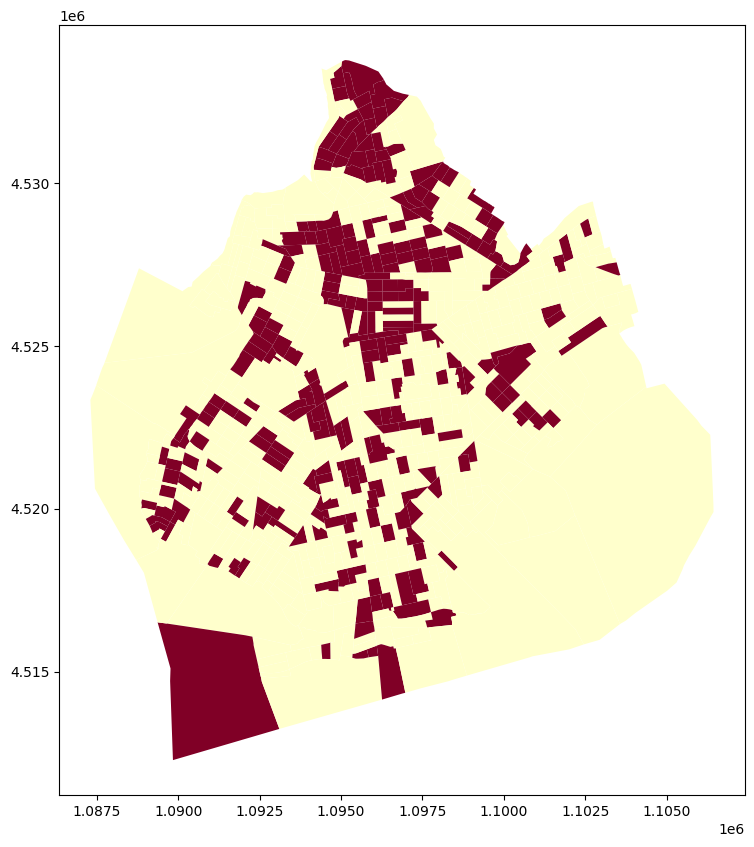

In [ ]:
# Increase in percent BA greater than MSA
bk_2000["increasing_education"] = (bk_2000["pct_ba_2010"]-bk_2000["pct_ba_2000"])>\
(bk_2000["pct_ba_msa_2010"]-bk_2000["pct_ba_msa_2000"])

# Increase in house value
bk_2000["increasing_house_value"] = bk_2000["median_value_2010"]-1.2612*bk_2000["median_value_2000"]>0

# Identify gentryifying tracts
bk_2000["gentrifying"] = bk_2000["gentrifiable"] & bk_2000["increasing_education"]& bk_2000["increasing_house_value"]

# Plot gentrifying tracts
bk_2000.plot(column = "gentrifying", cmap = "YlOrRd", figsize=(10, 10))
plt.show()

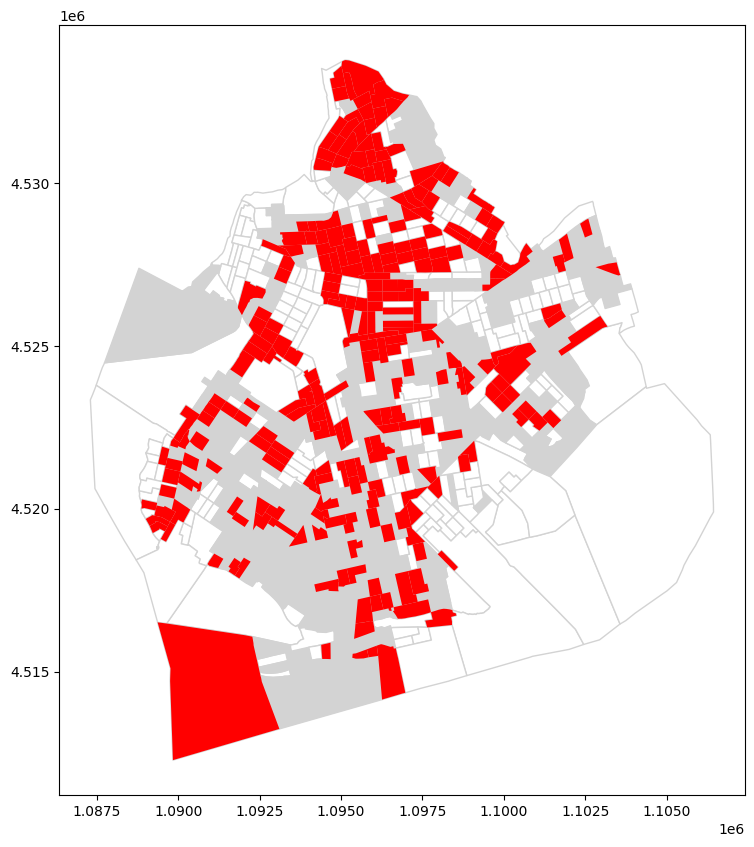

In [ ]:
# Create a basemap
basemap = bk_2000.plot(color= "white", edgecolor = "lightgray", figsize=(10, 10))

# Plot gentrifiable tracts
gentrifiable_tracts = bk_2000[bk_2000["gentrifiable"]== True]
gentrifiable_tracts.plot(ax = basemap, color = "lightgray")

# Plot gentrifying tracts
gentrifying_tracts = bk_2000[bk_2000["gentrifying"]==True]
gentrifying_tracts.plot(ax = basemap, color = "red")
plt.show()